<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_4_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 4
## Multiclass Classification

**Author:** Brad Sheese

---

## Introduction: Beyond Binary

So far we've been predicting binary outcomes: default or not. But many real problems have 3+ categories: wine type, disease severity, customer segment.

In this notebook, we switch to the **Wine dataset** to explore what happens when there are 3+ classes. We'll learn how models extend from binary to multiclass, and how to evaluate them properly.

**Note:** This is a different dataset with a different problem — but the same evaluation principles apply.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain the difference between One-vs-Rest (OvR) and Softmax (Multinomial) multiclass strategies.
2. Interpret multiclass confusion matrices and classification reports.
3. Understand macro, weighted, and micro averaging strategies.

## Section 1: The Wine Dataset

The Wine dataset contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (varieties). Our task: predict which of the three cultivars a wine belongs to based on its chemical properties.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Wine Dataset Properties:")
print(f"Classes: {wine.target_names}")
print(f"Class Distribution: {np.bincount(y_wine)}")
print(f"Features: {len(wine.feature_names)}")

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)
scaler_w = StandardScaler()
X_w_train_s = scaler_w.fit_transform(X_w_train)
X_w_test_s = scaler_w.transform(X_w_test)

Wine Dataset Properties:
Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]
Features: 13


## Section 2: Multiclass Strategies (OvR vs. Softmax)

Standard algorithms like logistic regression are binary by nature. To handle K classes, they use one of two strategies:

1.  **One-vs-Rest (OvR):** The model trains K separate binary classifiers. (Class 0 vs. Not-0, Class 1 vs. Not-1, etc.) The winner is the one with the highest probability.
2.  **Softmax (Multinomial):** The model has K outputs that are forced to sum to 1.0. This is a single, more complex optimization problem that considers all classes simultaneously.

Let's compare both strategies on the wine dataset.

OvR Test Accuracy:      1.000
Softmax Test Accuracy:  0.972


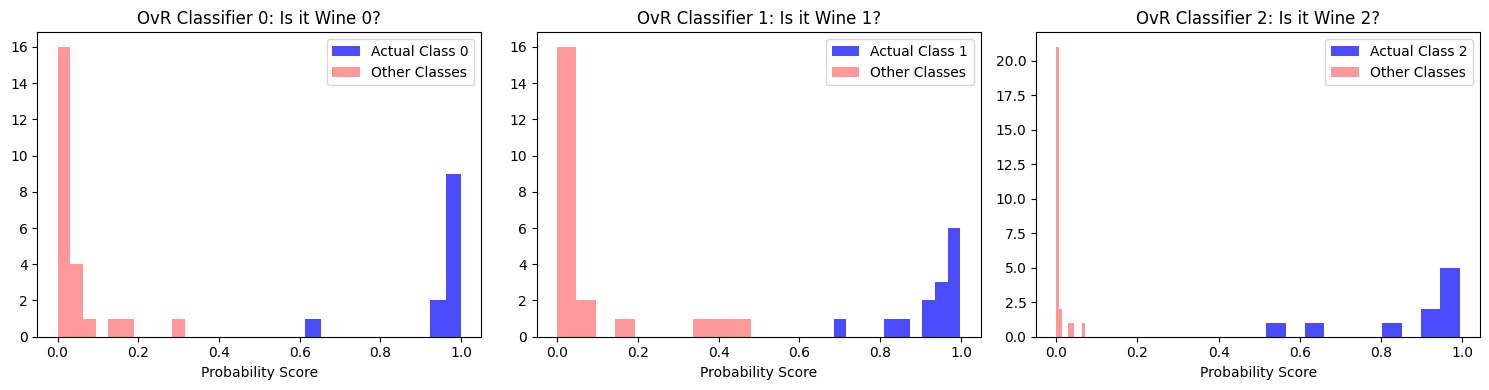

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# OvR strategy (using OneVsRestClassifier wrapper)
ovr_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_lr.fit(X_w_train_s, y_w_train)

# Softmax (Multinomial) strategy — this is the default in modern sklearn
softmax_lr = LogisticRegression(max_iter=1000, random_state=42)
softmax_lr.fit(X_w_train_s, y_w_train)

print(f"OvR Test Accuracy:      {ovr_lr.score(X_w_test_s, y_w_test):.3f}")
print(f"Softmax Test Accuracy:  {softmax_lr.score(X_w_test_s, y_w_test):.3f}")

# Visualize OvR probability distributions
y_w_proba_ovr = ovr_lr.predict_proba(X_w_test_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].hist(y_w_proba_ovr[y_w_test == i, i], bins=10, alpha=0.7, label=f'Actual Class {i}', color='blue')
    axes[i].hist(y_w_proba_ovr[y_w_test != i, i], bins=10, alpha=0.4, label='Other Classes', color='red')
    axes[i].set_title(f'OvR Classifier {i}: Is it Wine {i}?')
    axes[i].set_xlabel('Probability Score')
    axes[i].legend()
plt.tight_layout()
plt.show()

### Reading the OvR Histograms

Each plot shows one binary classifier's probability scores:

- **Blue bars** are wines that actually belong to that class. They should cluster near 1.0 (the classifier is confident).
- **Red bars** are wines from other classes. They should cluster near 0.0 (the classifier correctly rejects them).

Where the blue and red distributions overlap, the classifier is confused. Notice that Classifier 1 (middle plot) has the most overlap — some non-class-1 wines look enough like class 1 to get moderate probability scores. This is where misclassifications happen.

## Section 3: Multiclass Evaluation

When we have 3 classes, our confusion matrix becomes a 3×3 grid. Let's train a Random Forest on all 13 features and see where it's mixing up the wine types.

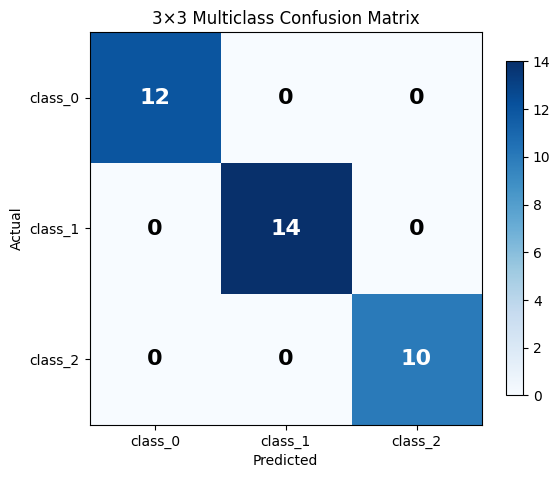


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [3]:
# Train a Random Forest on ALL 13 features
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_w_train_s, y_w_train)
y_w_pred = model.predict(X_w_test_s)

cm = confusion_matrix(y_w_test, y_w_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(wine.target_names)
ax.set_yticklabels(wine.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('3×3 Multiclass Confusion Matrix')

# Add labels with counts
for i in range(3):
    for j in range(3):
        label = f'{cm[i, j]}'
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, label, ha='center', va='center', fontsize=16, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

### Reading the Multiclass Report

- **Per-class precision/recall** tells you how well the model handles each wine type individually. Some cultivars may be easier to distinguish than others.
- **Macro avg** treats all three classes equally, regardless of how many samples each has. This is the fairest measure when classes are balanced.
- **Weighted avg** weights each class by its support (number of samples). Since the wine dataset is roughly balanced, macro and weighted averages will be similar.
- **Micro avg** computes the metric globally across all samples. For precision and recall, this is equivalent to accuracy when every sample has exactly one label.

Notice that the confusion matrix diagonal shows correct predictions, while off-diagonal cells show which classes the model confuses. If class 0 and class 2 are frequently mixed up, those two cultivars share similar chemical properties.

### Your Turn

1. Train an OvR model on the wine dataset. Which class is hardest to distinguish? (Hint: look at the per-class recall in the classification report.)
2. Imagine a dataset with 90 samples of class A and 10 of class B. A model gets all A right but misses all B. What are the macro, weighted, and micro precision scores?
3. Look at the confusion matrix. Which two wine cultivars does the model confuse most often? What might explain this?

## Conclusion

We've extended classification from binary to multiclass. Key takeaways:

1. **OvR trains K independent binary classifiers**; Softmax trains one model with K competing outputs.
2. **Multiclass confusion matrices** show exactly which classes the model confuses.
3. **Macro vs. weighted vs. micro averaging** — choose based on whether you care equally about all classes (macro) or about overall performance (weighted/micro).

In the next notebook, we'll pull back the curtain to see how these models actually carve up the feature space — visualizing **decision boundaries** and exploring **feature importance**.